In [1]:
import numpy as np

import simple_autograd as sa

import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Создадим простую НС, состоящую из наших блоков

In [2]:
class NeuralNetwork:
    def __init__(self, in_features, out_features):
        self.model = sa.Sequential(
            sa.Linear(in_features, 64),
            sa.ReLU(),
            sa.Linear(64, 32),
            sa.Tanh(),
            sa.Linear(32, 16),
            sa.Sigmoid(),
            sa.Linear(16, out_features)
        )
    
    def forward(self, x):
        return self.model.forward(x)
    
    def backward(self, grad_output):
        return self.model.backward(grad_output)
    
    def train(self):
        self.model.train()
    
    def eval(self):
        self.model.eval()
    
    def get_trainable_layers(self):
        """
        Получение всех слоев с обучаемыми параметрами
        """
        trainable_layers = []
        for layer in self.model.layers:
            if hasattr(layer, 'update_weights'):
                trainable_layers.append(layer)
        return trainable_layers

model_reg = NeuralNetwork(1, 1)
model_clf = NeuralNetwork(2, 2)

In [3]:
def train_mlp(model, x_train, y_train, opt, loss_f, n_epochs=20):
    
    loss_history = []
    model.train()
    trainable_layers = model.get_trainable_layers()
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        for x, y in zip(x_train, y_train):

            # подгоняем к нормальным размерностям
            x = np.asarray(x).reshape(1, -1)
            y = np.asarray(y).reshape(1, -1)
            
            opt.zero_grad(trainable_layers)
            
            predictions = model.forward(x)
            loss = loss_f.forward(predictions, y)
            loss_grad = loss_f.backward()
            
            model.backward(loss_grad)

            opt.step()
            for layer_id, layer in enumerate(trainable_layers):
                opt.update(layer, layer_id)

            epoch_loss += loss
            
        loss_history.append(epoch_loss / len(x_train))

    return loss_history

In [4]:
optimizer = sa.Adam()
reg_loss = sa.MSELoss()
clf_loss = sa.CrossEntropyLoss()

# ✅ Решим задачу регрессии

Будем предсказывать значение синуса на [-2$\pi$ , 2$\pi$ ]

In [5]:
X_reg = np.linspace(-2*np.pi, 2*np.pi, 200).reshape(-1, 1)
y_reg = np.sin(X_reg)

In [6]:
reg_loss = train_mlp(model_reg, X_reg, y_reg, optimizer, reg_loss)

model_reg.eval()
predictions = model_reg.forward(X_reg)

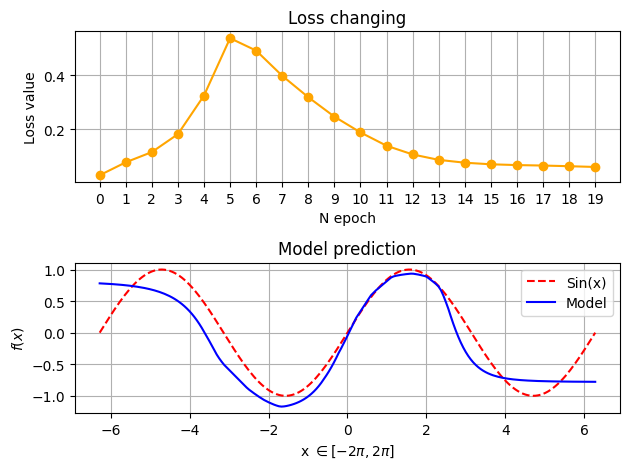

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1)

x_loss = np.arange(len(reg_loss))
ax1.plot(x_loss,
         reg_loss,
         marker='o',
         color='orange',
         label='MSE Loss'
        )
ax1.set_title('Loss changing')
ax1.set_xticks(x_loss)
ax1.set_xlabel('N epoch')
ax1.set_ylabel('Loss value')
ax1.grid(True)

ax2.plot(X_reg,
         y_reg,
         linestyle='--',
         color='red',
         label='Sin(x)'
        )
ax2.plot(X_reg,
         predictions,
         color='blue',
         label='Model'
        )
ax2.set_title('Model prediction')
ax2.set_xlabel('x $\in [-2\pi, 2\pi]$')
ax2.set_ylabel('$f(x)$')
ax2.grid(True)

plt.tight_layout()
plt.legend()
plt.show()

# ✅ Решим задачу классификации

Будем  решать задачу XOR

In [8]:
from sklearn.datasets import make_moons

X_clf, y_clf = make_moons(
    n_samples=500,
    noise=0.15,
    random_state=42
)

X_clf = X_clf.astype(np.float32)
y_clf = y_clf.astype(int)

In [9]:
clf_loss = train_mlp(model_clf, X_clf, y_clf, optimizer, clf_loss)

model_clf.eval()
predictions = model_clf.forward(X_clf)

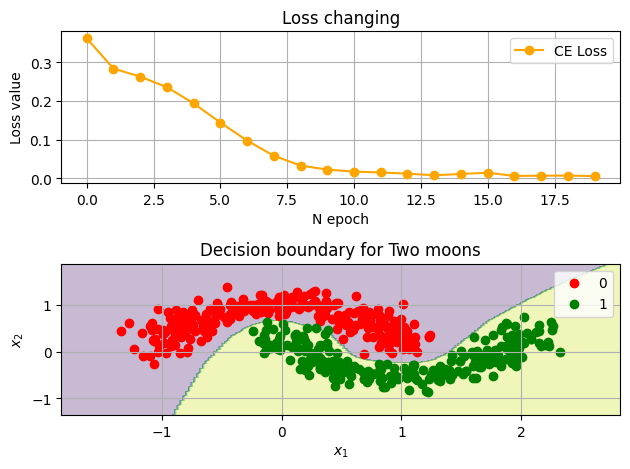

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1)

x_loss = np.arange(len(clf_loss))
ax1.plot(x_loss, clf_loss, marker='o', color='orange', label='CE Loss')
ax1.set_title('Loss changing')
ax1.set_xlabel('N epoch')
ax1.set_ylabel('Loss value')
ax1.grid(True)
ax1.legend()

# decision boundary
xx, yy = np.meshgrid(
    np.linspace(X_clf[:, 0].min() - 0.5, X_clf[:, 0].max() + 0.5, 200),
    np.linspace(X_clf[:, 1].min() - 0.5, X_clf[:, 1].max() + 0.5, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
logits = model_clf.forward(grid)
pred_grid = np.argmax(logits, axis=1).reshape(xx.shape)

ax2.contourf(xx, yy, pred_grid, alpha=0.3)

ax2.scatter(X_clf[np.where(y_clf == 0), 0], X_clf[np.where(y_clf == 0), 1], color='red', label='0')
ax2.scatter(X_clf[np.where(y_clf == 1), 0], X_clf[np.where(y_clf == 1), 1], color='green', label='1')

ax2.set_title('Decision boundary for Two moons')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()